<a href="https://colab.research.google.com/github/priya10241/Virality/blob/main/ViralityModelTrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv("final_training_data.csv")

In [3]:
df_test = pd.read_csv("final_testing_data.csv")

In [4]:
df_train.head()

,title_length,title_sentiment,word_count,unique_word_ratio,exclamation_count,question_mark_present,uppercase_ratio,contains_numbers,emotion_scores,sentence_embedding_0,...,sentence_embedding_11,sentence_embedding_12,sentence_embedding_13,sentence_embedding_14,sentence_embedding_15,sentence_embedding_16,sentence_embedding_17,sentence_embedding_18,sentence_embedding_19,viral
0,20.0,0.35,5.0,1.0,0.0,0.0,0.050000,0.0,0.55,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,41.0,0.80,9.0,1.0,0.0,0.0,0.048780,0.0,0.70,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,8.0,-0.50,2.0,1.0,0.0,0.0,0.250000,0.0,1.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,8.0,-0.50,2.0,1.0,0.0,0.0,0.250000,0.0,1.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,93.0,0.00,13.0,1.0,0.0,0.0,0.021505,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [5]:
from sklearn.ensemble import RandomForestClassifier

In [6]:
X = df_train.drop(columns=['viral'])
y = df_train['viral']

In [7]:
critic_model = RandomForestClassifier(n_estimators=100, random_state=42)
critic_model.fit(X, y)

RandomForestClassifier(random_state=42)

--- FINAL TEST RESULTS ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      3613
           1       0.96      0.47      0.63       525

    accuracy                           0.93      4138
   macro avg       0.94      0.73      0.79      4138
weighted avg       0.93      0.93      0.92      4138



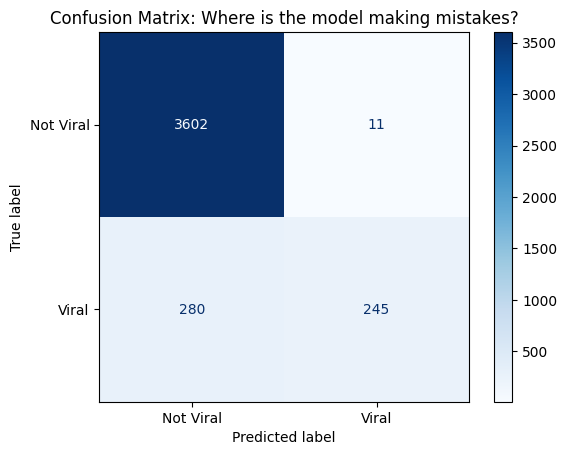

In [8]:

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X_test = df_test.drop(columns=['viral'])
y_test = df_test['viral']

y_pred_test = critic_model.predict(X_test)

print("--- FINAL TEST RESULTS ---")
print(classification_report(y_test, y_pred_test))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Viral', 'Viral'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Where is the model making mistakes?')
plt.show()

In [10]:

import pickle

filename = 'virality_scorer_model.pkl'

with open(filename, 'wb') as file:
    pickle.dump(critic_model, file)